In [1]:
!pip install micrograd

from micrograd.engine import Value

a = Value(-4.0)
b = Value(2.0)
c = a + b
d = a * b + b**3
c += c + 1
c += 1 + c + (-a)
d += d * 2 + (b + a).relu()
d += 3 * d + (b - a).relu()
e = c - d
f = e**2
g = f / 2.0
g += 10.0 / f

print(f'{g.data : .4f}') # g = 24.7041 : résultat du forward pass (calcul direct de g)
g.backward()
print(f'{a.grad : .4f}') # ∂g/∂a = 138.8338 : dérivée partielle de g par rapport à a (b fixé)
print(f'{b.grad : .4f}') # ∂g/∂b = 645.5773 : dérivée partielle de g par rapport à b (a fixé) 

# On déduit que le moteur Value fait maintenant tourner correctement toute la chaîne :
# addition, multiplication, puissance, division, négation, ReLU, et l'accumulation +=
# le tout combiné dans un seul graphe de calcul, avec une backpropagation qui donne le bon résultat.

 24.7041
 138.8338
 645.5773


In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline 

0.0002999999981767587

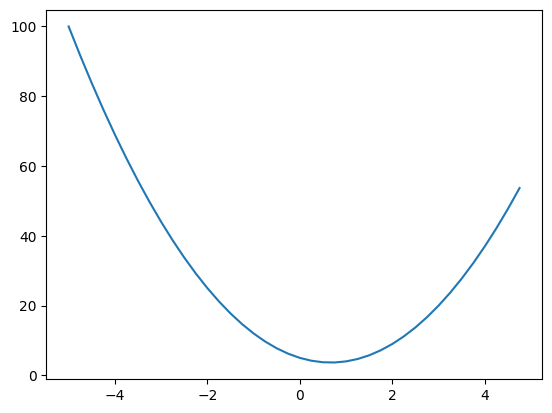

In [3]:
# Cas 1 : Fonction à une seule variable
def f(x) :
    return 3*x**2 - 4*x + 5

xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys) # L'allure de la courbe de ys en fonction de xs

h = 0.0001
x = 2/3
(f(x+h) - f(x))/h # Tangente horizontale au point 2/3

In [4]:
# Cas 2 : Fonction à plusieurs variables

h = 0.0001

# Variables d'entrée
a = 2.0
b = -3.0
c = 10.0

d1 = a * b + c 
a += h # On peut changer même b ou c pour évaluer leur impact sur le résultat final
d2 = a * b + c 

print('d1 :', d1) # d1 : 4.0
print('d2 :', d2) # d2 : 3.999699999999999
print('pente :', (d2 - d1)/h) # ∂d/∂a = -3.000000000010772

d1 : 4.0
d2 : 3.999699999999999
pente : -3.000000000010772


In [5]:
class Value :
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0 # Initialisation du gradiant du poids (data) sur le resultat de al fonction de perte (Loss Function)
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    # Nous devons définir une méthode à ajouter à la valeur de l’objet, sinon nous rencontrons l’erreur
    # unsupported operand type(s) for +: 'Value' and 'Value'
    def __add__(self, other):
        return Value(self.data + other.data, (self, other), '+')

    # Même chose pour les autres opérateurs
    # Pour la multiplication :
    def __mul__(self, other):
        return Value(self.data * other.data, (self, other), '*')


    # On implémente la fonction d'activation : tanh
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')
        return out



        
a = Value(2.0, label='a')
print(a) # Value(data=2.0)
b = Value(-3.0,label='b')
c = Value(10.0, label = 'c')
e = a * b ; e.label = 'e'
d = e + c ; d.label = 'd'
f =  Value(-2.0, label = 'f')
L = d * f; L.label = 'L'

print(d._prev) # Les fils de d sont : {Value(data=-6.0), Value(data=10.0)}
print(d._op) # L'opérateur utilisé pour obtenir d est : +

Value(data=2.0)
{Value(data=-6.0), Value(data=10.0)}
+


In [6]:
# Création d'un graphe dans Graphviz IPA (API) pour une plus bonne visualisation des résultats
from graphviz import Digraph

def trace(root):
    # Pour creer un ensemble contenant tous les arêtes et les sommets dans un graphe
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR : du gauche vers la droite (on a aussi TB : du haut vers le bas..etc) 

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # Pour chaque valeur (Value) on cree un sommet rectangulaire ('record')
        dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape = 'record') # %.4f est un espace réservé à un nombre décimal, avec 4 chiffres après la virgule.
        if n._op:
            # Si le sommet est un resultat d'une operation, on cree un sommet pour l'operateur
            dot.node(name = uid + n._op, label = n._op)
            # Puis on la connect au sommet de la valeur
            dot.edge(uid + n._op, uid)

    for n1,n2 in edges:
        # Connection de n1 avec le sommet de l'operatur de n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    return dot

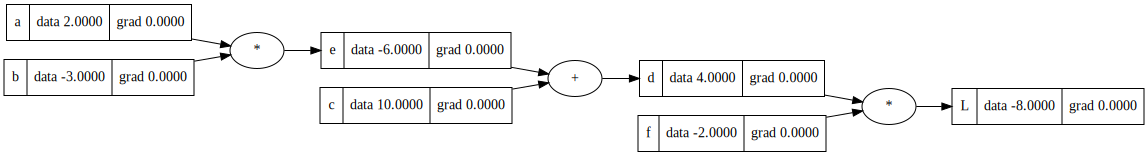

In [7]:
draw_dot(L) # Visualisation du sommet L et comment on l'a obtenu

**Les gradients ci-dessus de chaque sommet obtenus par backpropagation manuelle**

In [8]:
# En faisant un test d'optimisation qui a pour raison l'augmentation de L (= -8.0 maintenant)
a.data += 0.001 * a.grad
b.data += 0.001 * b.grad
c.data += 0.001 * c.grad
f.data += 0.001 * f.grad

e = a * b
d = e + c 
L = d * f

print(L) # Value(data=-7.9439519999999995)

Value(data=-8.0)


 **On passe a un exemple plus concret : Perceptron Multicouche (MLP)**
- Un *perceptron multicouche* selon Karpathy est un graphe qui contient une couche d'entrée (Input), une couche de sortie (Output) et au moins une couche cachée (Hidden).
- Un des modèles mathématiques d'un neurone est schématisé par :
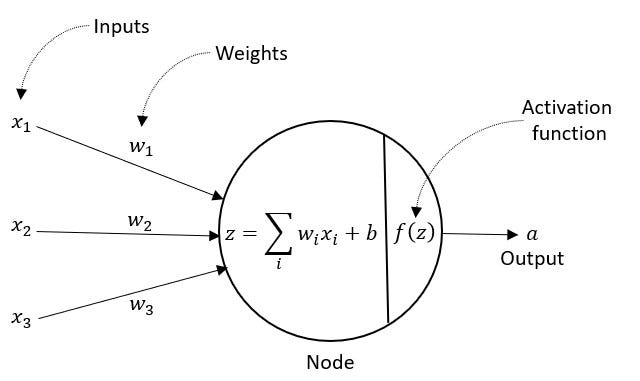!

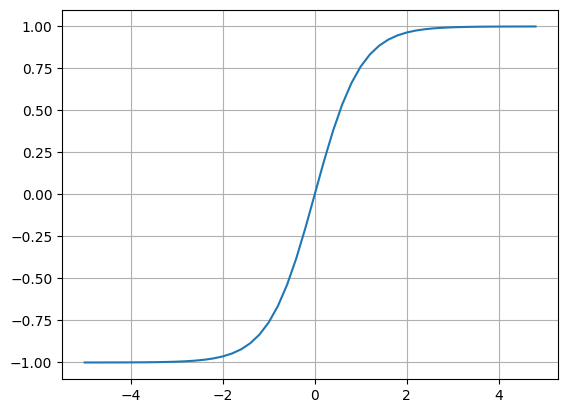

In [9]:
# On prend une fonction d'activation f : x -> tanh(x)

plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2))); plt.grid();

In [10]:
# On considère les entrées suivantes x1, x2
x1 = Value(2.0, label= 'x1')
x2 = Value(0.0, label= 'x2')
# et on a les poids de ces neurones respectivement w1, w2
w1 = Value(-3.0, label= 'w1')
w2 = Value(1.0, label= 'w2')
# et on a le biais du neurone
b = Value(6.8813735870195432, label= 'b')

x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o' # Output : sortie de notre fonction d'activation


In [11]:
# En faisant une backpropagation manuelle
o.grad = 1.0

# ∂o/∂n = 1-tanh(n)**2 = 1-o**2 = 0.4999999 = 0.5
n.grad = 0.5

# Puisque n = (x1w1+x2w2) + b, alors ∂o/∂b = 1 et ∂o/∂(x1w1+x2w2) = 1
b.grad = 0.5
x1w1x2w2.grad = 0.5

# Or (x1w1+x2w2) = (x1w1)+(x2w2), alors ∂o/∂(x1w1) = 1 et ∂o/∂(x2w2) = 1
x1w1.grad = 0.5
x2w2.grad = 0.5

# On a ∂o/∂x1 = ∂o/∂n * ∂n/∂(x1w1+x2w2) * ∂(x1w1+x2w2)/∂(x1w1) * ∂(x1w1)/∂x1
x1.grad = -1.5

# On a ∂o/∂x1 = ∂o/∂n * ∂n/∂(x1w1+x2w2) * ∂(x1w1+x2w2)/∂(x1w1) * ∂(x1w1)/∂w11
w1.grad = 1.0

# De meme :
x2.grad = 0.5
w2.grad = 0.0

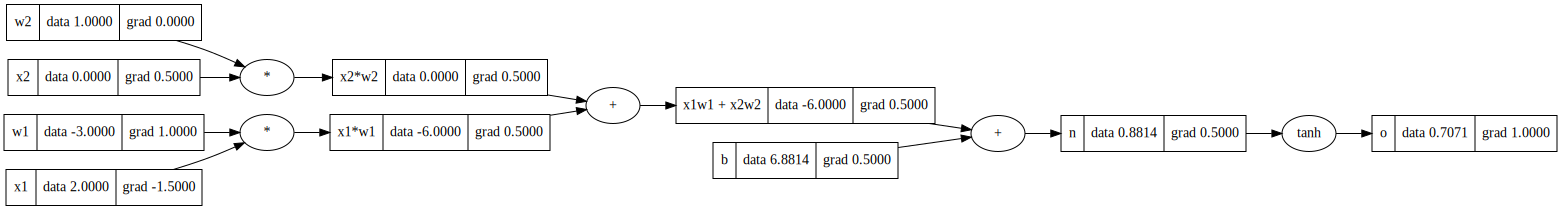

In [12]:
draw_dot(o)